In [159]:
import ssl
import urllib.request

ssl._create_default_https_context = ssl._create_unverified_context

In [78]:
# 📦 Standard Libraries
import re
import string
import math
import numpy as np
import pandas as pd
from argparse import Namespace

# 📚 Text Processing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# 🧠 Machine Learning & NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 🧬 Vectorization
from gensim.models import FastText

# 📊 Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go

# 🌌 Dimensionality Reduction
import umap.umap_ as umap


In [4]:
# === Download necessary NLTK data ===
# nltk.download("punkt")
# nltk.download("stopwords")
# nltk.download("wordnet")

FINE_TUNED_DIR = '../../pretained_or_finetune-models'
REVIEWS_DATASET_DIR = '../../dataset'
UTILS_DIR = '../../utils'
NLTK_DATA_PATH = f"{FINE_TUNED_DIR}/nltk_data"

nltk.data.path.append(NLTK_DATA_PATH)

# === Constants ===
STOPWORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()
CONST_VECTOR_SIZE = 50
CONST_DIM_WINDOWS = 3

In [5]:
def advanced_clean_text(text):
    if not isinstance(text, str):
        return "other"  # Handle non-string values safely
    
    # Define domain-specific stopwords
    custom_stopwords = {'point', 'points', 'interest', 'landmark', 'landmarks', 'site', 'sites'}  # Remove generic tourism terms
    
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[^a-z\s]', '', text)  # Remove special characters
    text = re.sub(r'\b(u|ur|b4)\b', 'you', text)  # Replace common abbreviations

    words = text.split()  # ✅ Fix: Use split() instead of word_tokenize()
    words = [LEMMATIZER.lemmatize(word) for word in words if word not in STOPWORDS]
    words = [word for word in words if word not in custom_stopwords and word not in string.punctuation]  # Remove tourism-related stopwords

    return ' '.join(words)  

In [6]:
combined_details_df = pd.read_parquet("../../frontend/inputs/combined_details.parquet")

In [7]:
combined_details_df.head(5)

,location_id,name,description,web_url,latitude,longitude,website,write_review,rating,rating_image_url,...,rating_2_review_count,rating_3_review_count,rating_4_review_count,rating_5_review_count,tags,trip_types_solo,trip_types_couples,trip_types_business,trip_types_family,trip_types_friends
0,456633,House of Opium,Located in the heart of the infamous Golden Tr...,https://www.tripadvisor.com/Attraction_Review-...,20.351446,100.081660,https://www.tourismthailand.org/Attraction/Hou...,https://www.tripadvisor.com/UserReview-g317131...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,34,210,363,413,"History Museums, Specialty Museums",105,440,9,148,184
1,23933132,Opium Bar,None,https://www.tripadvisor.com/Attraction_Review-...,13.739190,100.508500,http://www.opiumbarbangkok.com/,https://www.tripadvisor.com/UserReview-g293916...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,1,0,4,Bars & Clubs,0,3,0,0,2
2,7099963,Wat Phra That Doi Saket,None,https://www.tripadvisor.com/Attraction_Review-...,18.872380,99.139930,None,https://www.tripadvisor.com/UserReview-g196165...,4.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,5,31,44,Sacred & Religious Sites,9,26,0,14,21
3,1390125,Mae Ping River Cruise,Leave from the jetty at Wat Chai Mongkol and t...,https://www.tripadvisor.com/Attraction_Review-...,18.780819,99.005210,http://www.maepingrivercruise.com/,https://www.tripadvisor.com/UserReview-g293917...,3.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,43,98,127,102,Boat Tours,31,186,2,43,57
4,547675,Pai River,None,https://www.tripadvisor.com/Attraction_Review-...,19.359318,98.445305,None,https://www.tripadvisor.com/UserReview-g303916...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,6,46,58,52,Bodies of Water,30,56,1,15,46


In [8]:
combined_details_df['tags'] = combined_details_df['tags'].fillna("").astype(str)
combined_details_df['tags'].replace("", "other", inplace=True)

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_73904/4017882174.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_details_df['tags'].replace("", "other", inplace=True)


In [9]:
combined_details_df['label'] = combined_details_df['tags'].apply(lambda x: x.split(',')[0])

In [10]:

combined_details_df['tags'] = combined_details_df['tags'].apply(advanced_clean_text)
combined_details_df['tags']

0               history museum specialty museum
1                                      bar club
2                              sacred religious
3                                     boat tour
4                                    body water
                         ...                   
1761                                      beach
1762                                     bridge
1763    sacred religious architectural building
1764                                      beach
1765                                    lookout
Name: tags, Length: 1766, dtype: object

In [11]:
combined_details_df['label'] = combined_details_df['label'].apply(advanced_clean_text)
combined_details_df['label'] = combined_details_df['label'].fillna("").astype(str)
combined_details_df['label'].replace("", "other", inplace=True)
combined_details_df['label']

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_73904/348596639.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_details_df['label'].replace("", "other", inplace=True)


0         history museum
1               bar club
2       sacred religious
3              boat tour
4             body water
              ...       
1761               beach
1762              bridge
1763    sacred religious
1764               beach
1765             lookout
Name: label, Length: 1766, dtype: object

In [12]:
# แปลงข้อมูลเป็น String
tags = combined_details_df['tags'].astype(str)

# ใช้ TF-IDF Vectorizer
vectorizer = TfidfVectorizer(tokenizer=lambda x: x.lower().split(" "), stop_words='english')

# Fit Transform
X = vectorizer.fit_transform(tags)

# ดึง Feature Names (คำที่สำคัญ)
feature_names = np.array(vectorizer.get_feature_names_out())

# คำนวณ TF-IDF และเลือกคำที่มีค่ามากที่สุดในแต่ละแถว
important_words = []
for row in X:
    row_data = row.toarray().flatten()
    best_word_index = np.argmax(row_data)  # Index ของคำที่สำคัญที่สุด
    best_word = feature_names[best_word_index] if row_data[best_word_index] > 0 else None
    important_words.append(best_word)

# เพิ่มคอลัมน์ใหม่
combined_details_df["keyword"] = important_words

# ดูผลลัพธ์
(combined_details_df[["name", "tags", "keyword"]].head(10))

/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,name,tags,keyword
0,House of Opium,history museum specialty museum,museum
1,Opium Bar,bar club,bar
2,Wat Phra That Doi Saket,sacred religious,religious
3,Mae Ping River Cruise,boat tour,boat
4,Pai River,body water,body
5,Doi Chang Mub Arboretum,lookout,lookout
6,Tung Dok Bua Tong Doi Hua Mae Kum,garden,garden
7,Golden Triangle,,
8,Golden Triangle Tours - Day Tours,sightseeing tour,sightseeing
9,Bo Nam Ron Krung Ching,hot spring geyser,geyser


In [13]:
from collections import Counter


all_tags = [tag.strip() for tags in combined_details_df['tags'].dropna() for tag in tags.lower().split(", ")]
tag_counts = Counter(all_tags)

def select_most_frequent(tag_string):
    tags = tag_string.lower().split(", ")  # แก้ให้แยกคำตาม ", "
    return max(tags, key=lambda tag: tag_counts[tag]) if tags else None

combined_details_df["frequncy_keyword"] = combined_details_df["tags"].astype(str).apply(select_most_frequent)

print(combined_details_df[["tags", "frequncy_keyword"]].head())

                              tags                 frequncy_keyword
0  history museum specialty museum  history museum specialty museum
1                         bar club                         bar club
2                 sacred religious                 sacred religious
3                        boat tour                        boat tour
4                       body water                       body water


In [14]:
tag_counts

Counter({'': 223,
         'sacred religious': 210,
         'flea street market': 80,
         'spa': 76,
         'beach': 75,
         'specialty museum': 69,
         'gift specialty shop': 64,
         'nature wildlife area': 48,
         'waterfall': 45,
         'shopping mall': 28,
         'lookout': 27,
         'monument statue': 25,
         'island': 25,
         'bar club': 24,
         'park': 24,
         'body water': 23,
         'farm': 20,
         'cavern cave': 19,
         'national park': 17,
         'cooking class': 17,
         'historic': 16,
         'nature wildlife tour': 16,
         'history museum': 15,
         'scuba snorkeling': 14,
         'farmer market': 13,
         'mountain': 13,
         'garden': 12,
         'boat tour': 11,
         'zoo': 11,
         'golf course': 10,
         'bridge': 10,
         'taxi shuttle': 10,
         'ferry': 10,
         'hot spring geyser': 9,
         'neighborhood': 9,
         'art gallery': 9,
        

In [15]:
combined_details_df['label'].apply(type).value_counts()

label
<class 'str'>    1766
Name: count, dtype: int64

In [ ]:
args = Namespace(
    VECTOR_SIZE=300,
    VECTOR_WINDOW_SIZE=10,
    VECTOR_MIN_COUNT=1,
    VECTOR_METHOD=0
)

In [17]:
sentences = [tags.split(", ") for tags in combined_details_df['label'].dropna()]

In [ ]:
fasttext_model = FastText(sentences, vector_size=args.VECTOR_SIZE, window=args.VECTOR_WINDOW_SIZE, min_count=args.VECTOR_MIN_COUNT, sg=args.VECTOR_METHOD, epochs=20)

words = list(fasttext_model.wv.index_to_key)
vectors = [fasttext_model.wv[word] for word in words]

word_vectors = np.array([fasttext_model.wv[word] for word in words])

In [20]:
oov_vector = fasttext_model.wv["unseenword"]
oov_vector

array([ 1.20445591e-04,  5.83025743e-04, -2.53915845e-04,  5.96043421e-04,
       -1.18364675e-04, -6.50173053e-04, -7.43078999e-06, -2.01032031e-04,
        5.53272490e-04,  1.40356919e-04, -1.89257858e-04, -2.99028052e-05,
        4.88321675e-05, -3.43651118e-05,  1.83685755e-04, -2.79499538e-04,
        1.24197089e-04,  1.12606438e-04,  4.64877812e-05,  2.15204956e-04,
       -1.01932899e-04, -6.04774745e-04,  2.26455959e-04, -3.48730391e-04,
       -4.32477769e-04,  7.59188435e-04,  1.58976851e-04,  1.97457237e-04,
       -2.64717295e-04, -9.73245624e-05,  3.33968230e-04,  9.86684536e-05,
        5.04427706e-04,  3.53244570e-04, -2.65196606e-04, -1.61860487e-04,
        6.34458920e-05, -4.22653568e-04,  3.10557953e-04, -2.30940554e-04,
       -2.54022627e-04, -2.63774273e-04,  6.80564670e-04, -7.25177815e-04,
        2.82337365e-04, -2.89868040e-04, -5.76427439e-04,  4.15628136e-04,
        2.31080936e-04, -4.41960467e-04, -8.45062968e-05,  1.65154925e-04,
        5.13814506e-04,  

In [21]:
word_vectors[0]

array([-3.12364282e-04, -3.35072429e-04, -3.36168276e-04,  4.59939154e-04,
       -6.81595004e-04, -4.21761040e-04, -6.42580329e-04, -3.89399182e-04,
        9.53036288e-05, -2.71693134e-04,  5.76291292e-04,  8.47582589e-04,
       -7.32881250e-04,  1.53739747e-04, -6.08846167e-05, -6.29454553e-06,
        3.36808152e-04, -9.81236299e-05, -8.70418793e-04, -5.53497171e-04,
       -9.94450762e-04, -5.64843416e-04, -3.92959948e-04, -6.64497318e-04,
        5.72873512e-04, -4.78845643e-04, -9.91540364e-05,  1.01098885e-04,
        1.84507197e-04, -1.54178240e-03,  3.60674661e-04, -1.36064773e-04,
        2.75019247e-05, -4.92431827e-05, -2.43533708e-04, -1.29351523e-04,
        1.86779173e-04,  6.96795541e-05,  9.76699012e-05,  1.99539762e-04,
       -3.45947628e-04, -6.03985136e-05, -6.81009900e-04, -1.53266243e-03,
       -6.48686895e-04,  2.15246182e-04, -2.53659615e-04,  4.26963088e-04,
        4.59444622e-04, -2.58069689e-04,  1.86162666e-04, -5.07752411e-05,
        1.91193485e-05,  

In [22]:
sentences

[['history museum'],
 ['bar club'],
 ['sacred religious'],
 ['boat tour'],
 ['body water'],
 ['other'],
 ['garden'],
 ['other'],
 ['sightseeing tour'],
 ['hot spring geyser'],
 ['national park'],
 ['flea street market'],
 ['shopping mall'],
 ['specialty museum'],
 ['historic'],
 ['historic'],
 ['zoo'],
 ['other'],
 ['performance'],
 ['sacred religious'],
 ['sacred religious'],
 ['sacred religious'],
 ['monument statue'],
 ['geologic formation'],
 ['specialty museum'],
 ['architectural building'],
 ['other'],
 ['ancient ruin'],
 ['other'],
 ['other'],
 ['sacred religious'],
 ['sacred religious'],
 ['nature wildlife area'],
 ['spa'],
 ['zoo'],
 ['other'],
 ['waterfall'],
 ['farmer market'],
 ['natural history museum'],
 ['other'],
 ['specialty museum'],
 ['shopping mall'],
 ['mass transportation system'],
 ['farm'],
 ['cavern cave'],
 ['historic'],
 ['other'],
 ['other'],
 ['flea street market'],
 ['waterfall'],
 ['scuba snorkeling'],
 ['other'],
 ['other'],
 ['other'],
 ['other'],
 ['sh

In [63]:
import sklearn

print(sklearn.__version__) 

1.6.1


In [31]:
word_vectors = normalize(word_vectors)
cosine_sim_matrix = cosine_similarity(word_vectors)

for threshold in [0.35, 0.4, 0.5, 0.6, 0.7]:
    dbscan = DBSCAN(eps=threshold, min_samples=2, metric="cosine")  
    word_clusters_dbscan = dbscan.fit_predict(word_vectors)
    
    n_clusters = len(set(word_clusters_dbscan)) - (1 if -1 in word_clusters_dbscan else 0)
    n_noise = list(word_clusters_dbscan).count(-1)
    
    print(f"\n🔹 Clustering with threshold {threshold}")
    print(f"  - Number of clusters: {n_clusters}")
    print(f"  - Number of noise points: {n_noise}")

    # Evaluate เฉพาะถ้ามีมากกว่า 1 cluster
    if n_clusters > 1:
        sil_score = silhouette_score(word_vectors, word_clusters_dbscan, metric='cosine')
        dbi_score = davies_bouldin_score(word_vectors, word_clusters_dbscan)
        print(f"  ✅ Silhouette Score: {sil_score:.4f}")
        print(f"  ✅ Davies-Bouldin Index: {dbi_score:.4f}")
    else:
        print("  ⚠️  Skipping evaluation: Only 1 cluster or all noise.")




🔹 Clustering with threshold 0.35
  - Number of clusters: 3
  - Number of noise points: 127
  ✅ Silhouette Score: -0.0271
  ✅ Davies-Bouldin Index: 1.4804

🔹 Clustering with threshold 0.4
  - Number of clusters: 5
  - Number of noise points: 123
  ✅ Silhouette Score: -0.0376
  ✅ Davies-Bouldin Index: 1.5425

🔹 Clustering with threshold 0.5
  - Number of clusters: 9
  - Number of noise points: 115
  ✅ Silhouette Score: -0.0230
  ✅ Davies-Bouldin Index: 1.5913

🔹 Clustering with threshold 0.6
  - Number of clusters: 14
  - Number of noise points: 91
  ✅ Silhouette Score: 0.0149
  ✅ Davies-Bouldin Index: 2.0246

🔹 Clustering with threshold 0.7
  - Number of clusters: 10
  - Number of noise points: 74
  ✅ Silhouette Score: 0.0190
  ✅ Davies-Bouldin Index: 2.6275


In [32]:
dbscan = DBSCAN(eps=0.6, min_samples=2, metric="cosine")  
word_clusters_dbscan = dbscan.fit_predict(word_vectors)

# ✅ Store clustering results
agg_clusters = {words[i]: word_clusters_dbscan[i] for i in range(len(words))}


In [77]:
# ✅ Print top 5 words in each cluster (Agglomerative)
cluster_word_map = {}
print("\n🔹 DBSCAN Clustering (Cosine Similarity):")
for cluster_id in set(word_clusters_dbscan):
    cluster_words = [word for word in words if agg_clusters[word] == cluster_id]
    cluster_word_map[cluster_id] = cluster_words
    print(f"Cluster {cluster_id}: {', '.join(cluster_words[:15])} ...")


🔹 DBSCAN Clustering (Cosine Similarity):
Cluster 0: nature wildlife area, nature wildlife tour ...
Cluster 1: national park, educational ...
Cluster 2: historic, scenic walking area, historic walking area ...
Cluster 3: boat tour, speed boat tour, food tour, night tour, bus tour ...
Cluster 4: history museum, art museum, natural history museum, science museum, military museum, military base facility ...
Cluster 5: architectural building, government building ...
Cluster 6: theme park, state park ...
Cluster 7: hiking trail, hiking camping tour, sightseeing tour, horseback riding tour, climbing tour, walking tour, biking trail ...
Cluster 8: gear rental, boat rental, selfguided tour rental ...
Cluster 9: cultural event, cultural tour ...
Cluster 10: theater, movie theater ...
Cluster 11: private tour, bike tour ...
Cluster 12: jazz club bar, blue club bar ...
Cluster 13: airport shop, airport lounge ...
Cluster -1: other, sacred religious, flea street market, spa, beach, specialty museu

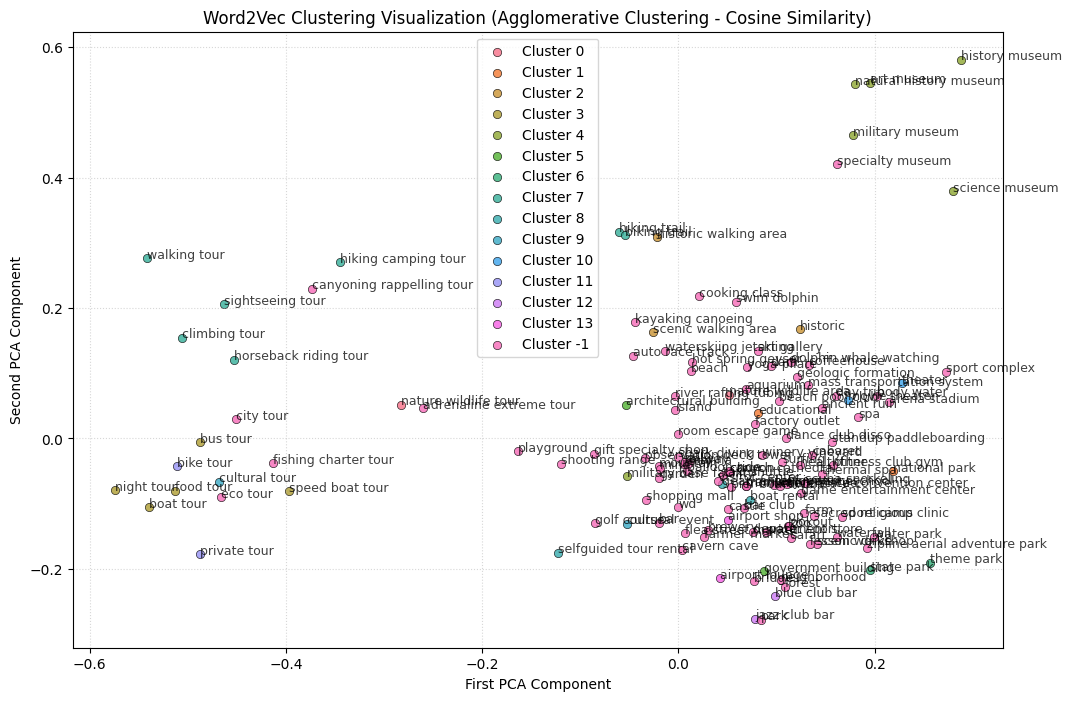

In [34]:
pca = PCA(n_components=2)
word_vectors_2d = pca.fit_transform(word_vectors)

# ✅ Define colors for clusters
num_clusters = len(set(word_clusters_dbscan))
palette = sns.color_palette("husl", num_clusters)

# ✅ Scatter plot with cluster colors
plt.figure(figsize=(12, 8))
for cluster_id in set(word_clusters_dbscan):
    idx = np.where(word_clusters_dbscan == cluster_id)
    plt.scatter(word_vectors_2d[idx, 0], word_vectors_2d[idx, 1], 
                label=f"Cluster {cluster_id}", color=palette[cluster_id], alpha=0.8, edgecolors='k', linewidth=0.5)

# ✅ Annotate words more clearly
for i, word in enumerate(words):
    plt.annotate(word, (word_vectors_2d[i, 0], word_vectors_2d[i, 1]), fontsize=9, alpha=0.75)

# ✅ Improve visualization settings
plt.title("Word2Vec Clustering Visualization (Agglomerative Clustering - Cosine Similarity)")
plt.xlabel("First PCA Component")
plt.ylabel("Second PCA Component")
plt.grid(True, linestyle='dotted', alpha=0.5)
plt.legend()
plt.show()

/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


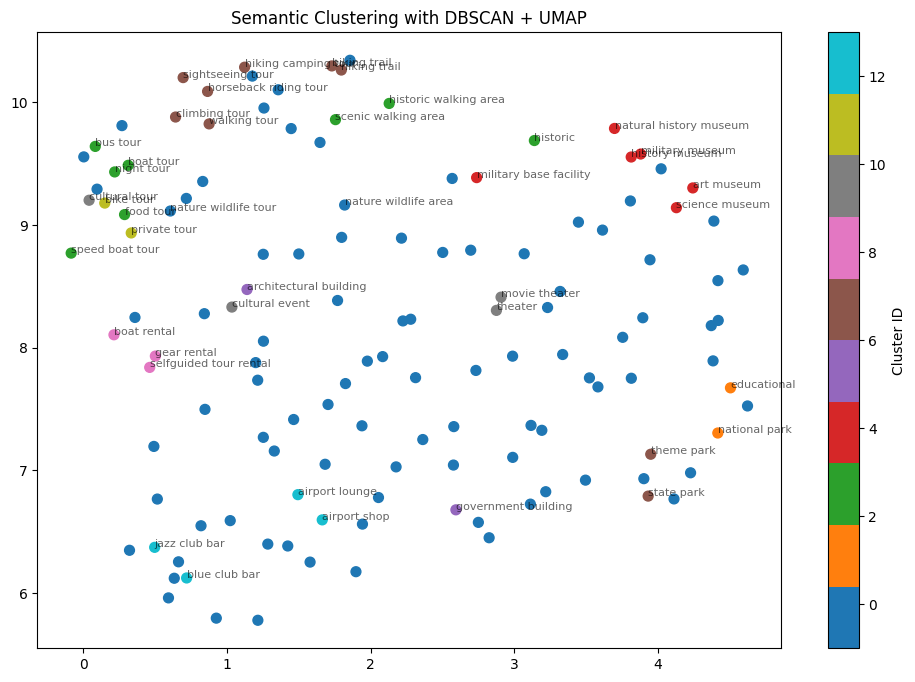

In [43]:
X = np.array(word_vectors)
labels = np.array(word_clusters_dbscan)

# Reduce dimensions to 2D
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine')
embedding = reducer.fit_transform(X)

# Plot with cluster colors
plt.figure(figsize=(12, 8))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='tab10', s=50)

# Optional: Annotate with words
for i, word in enumerate(words):
    if labels[i] != -1:  # -1 = noise
        plt.annotate(word, (embedding[i, 0], embedding[i, 1]), fontsize=8, alpha=0.6)

plt.title("Semantic Clustering with DBSCAN + UMAP")
plt.colorbar(scatter, label='Cluster ID')
plt.show()

/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_9392/3607167339.py:16: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


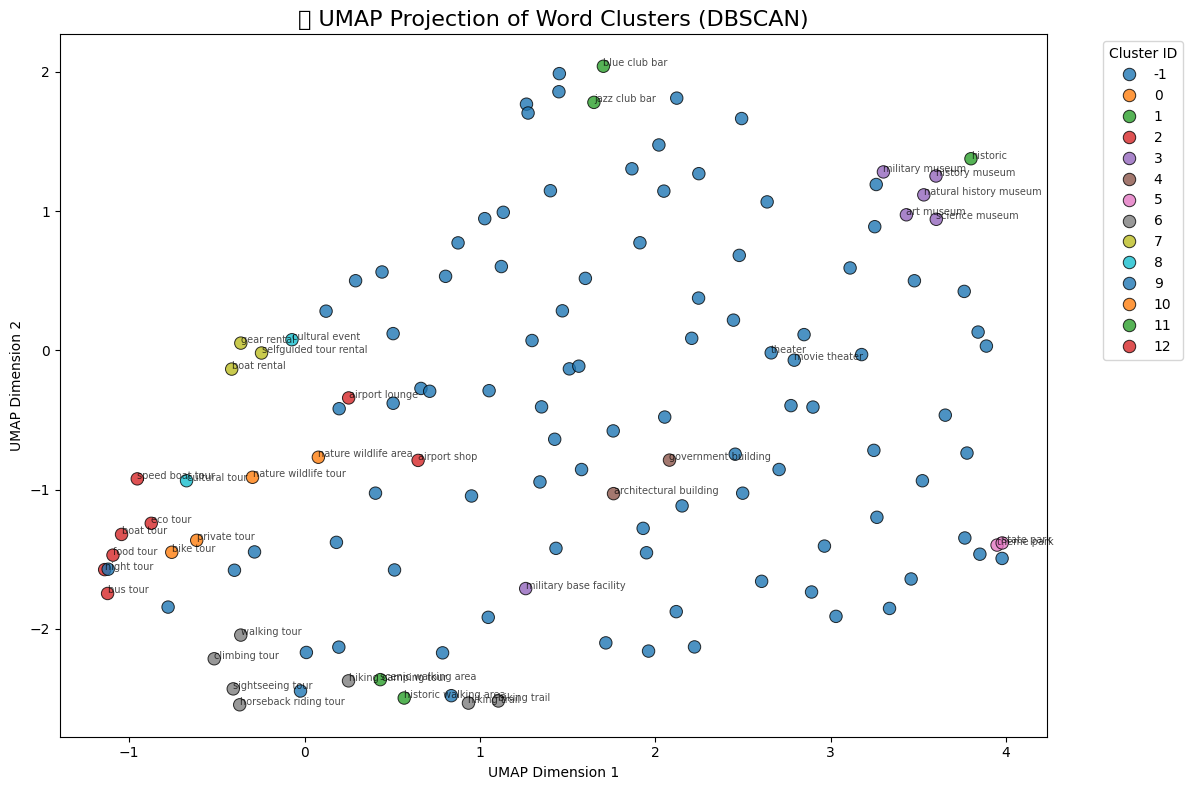

In [56]:
umap_embedding = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine").fit_transform(word_vectors)

# Step 2: Plot clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x=umap_embedding[:, 0], y=umap_embedding[:, 1], hue=word_clusters_dbscan, palette="tab10", s=80, alpha=0.8, edgecolor="k")

# Optional: Annotate words
for i, word in enumerate(words):
    if word_clusters_dbscan[i] != -1:  # skip noise if needed
        plt.text(umap_embedding[i, 0], umap_embedding[i, 1], word, fontsize=7, alpha=0.7)

plt.title("🔍 UMAP Projection of Word Clusters (DBSCAN)", fontsize=16)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Cluster ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [44]:
from collections import defaultdict

cluster_words_dict = defaultdict(list)
for word, label in zip(words, word_clusters_dbscan):
    cluster_words_dict[label].append(word)

# Print top 10 from each cluster
for cid, wlist in cluster_words_dict.items():
    print(f"\n🔹 Cluster {cid} ({len(wlist)} words):\n" + ", ".join(wlist[:10]) + " ...")



🔹 Cluster -1 (91 words):
other, sacred religious, flea street market, spa, beach, specialty museum, gift specialty shop, waterfall, shopping mall, park ...

🔹 Cluster 0 (2 words):
nature wildlife area, nature wildlife tour ...

🔹 Cluster 1 (2 words):
national park, educational ...

🔹 Cluster 2 (3 words):
historic, scenic walking area, historic walking area ...

🔹 Cluster 3 (5 words):
boat tour, speed boat tour, food tour, night tour, bus tour ...

🔹 Cluster 4 (6 words):
history museum, art museum, natural history museum, science museum, military museum, military base facility ...

🔹 Cluster 5 (2 words):
architectural building, government building ...

🔹 Cluster 6 (2 words):
theme park, state park ...

🔹 Cluster 7 (7 words):
hiking trail, hiking camping tour, sightseeing tour, horseback riding tour, climbing tour, walking tour, biking trail ...

🔹 Cluster 8 (3 words):
gear rental, boat rental, selfguided tour rental ...

🔹 Cluster 9 (2 words):
cultural event, cultural tour ...

🔹 Clust

In [151]:
# ✅ Map DBSCAN clustering results to `combined_details_df['cluster']`
word_to_cluster = {word: cluster_id for word, cluster_id in zip(words, word_clusters_dbscan)}

# Function to assign cluster labels to `combined_details_df`
def assign_cluster(tags):
    tag_list = tags.split(", ")  # Convert tag string to list
    cluster_ids = [word_to_cluster.get(tag, -1) for tag in tag_list]  # Get clusters, default to -1 if not found
    
    # Return the most common cluster in case multiple tags belong to different clusters
    return max(set(cluster_ids), key=cluster_ids.count) if cluster_ids else -1  

# ✅ Apply function to assign clusters
combined_details_df['cluster'] = combined_details_df['label'].apply(assign_cluster)

In [148]:
# ✅ Filter rows where 'label' contains the word 'museum'
filtered_df = combined_details_df[combined_details_df['label'].str.contains('museum', case=False, na=False)]

# ✅ Get unique labels
unique_museum_labels = filtered_df['label'].unique()

# ✅ Display results
print("Unique Museum Labels:", unique_museum_labels)

Unique Museum Labels: ['history museum' 'specialty museum' 'natural history museum' 'art museum'
 'science museum' 'military museum']


In [152]:
combined_details_df[['name', 'label', 'cluster']]

,name,label,cluster
0,House of Opium,history museum,0
1,Opium Bar,bar club,-1
2,Wat Phra That Doi Saket,sacred religious,-1
3,Mae Ping River Cruise,boat tour,3
4,Pai River,body water,-1
...,...,...,...
1761,Chao Lao Beach,beach,-1
1762,Chao Lao Fish Bridge,bridge,-1
1763,Wat Burapa Temple,sacred religious,-1
1764,Kung Wiman Beach,beach,-1


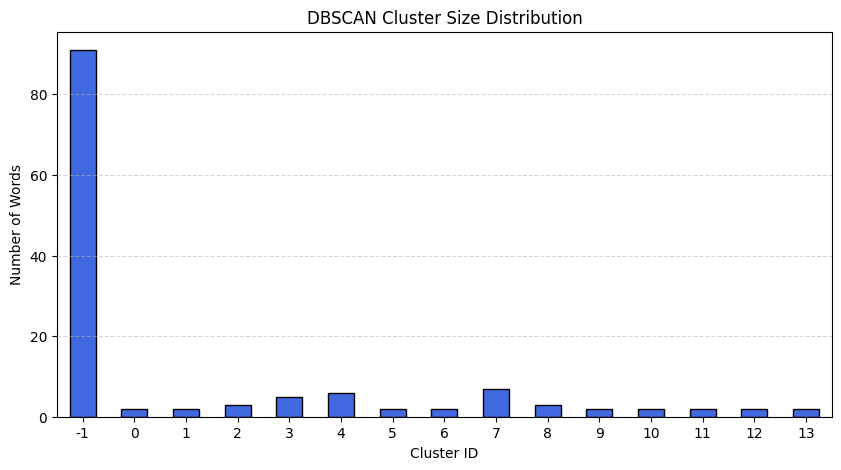

In [45]:

# ✅ Count cluster sizes
cluster_counts = pd.Series(word_clusters_dbscan).value_counts()

# ✅ Bar chart of cluster sizes
plt.figure(figsize=(10, 5))
cluster_counts.sort_index().plot(kind="bar", color="royalblue", edgecolor="black")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Words")
plt.title("DBSCAN Cluster Size Distribution")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [ ]:
# ✅ Count noise vs. clustered points
num_noise = list(word_clusters_dbscan).count(-1)
num_clustered = len(word_clusters_dbscan) - num_noise

# ✅ Labels and values
labels = ["Clustered Data", "Noise (Cluster -1)"]
values = [num_clustered, num_noise]
colors = ["royalblue", "crimson"]

# ✅ Plotly Pie Chart
fig = go.Figure(data=[go.Pie(
    labels=labels,
    values=values,
    hole=0.3,  # Donut style
    marker=dict(colors=colors, line=dict(color='#FFFFFF', width=2)),
    textinfo='label+percent',
    insidetextorientation='radial'
)])

fig.update_layout(
    title_text="📊 DBSCAN Noise Ratio",
    title_font_size=20,
    legend=dict(orientation="h", y=-0.1, x=0.3),
    margin=dict(t=60, b=0, l=0, r=0)
)

fig.show()


In [56]:
df_box = silhouette_df.copy()
df_box["Cluster"] = df_box["Cluster"].astype(str)

# ✅ Plot ด้วย Plotly Express
fig = px.box(
    df_box,
    y="Cluster",  # แนวนอน (Cluster เป็นแกน Y)
    x="Silhouette Score",
    color="Cluster",
    points="outliers",  # แสดง outliers ชัดเจน
    title="📦 Silhouette Score per Cluster (DBSCAN)",
    template="plotly_white",
)

fig.update_layout(
    yaxis_title="Cluster ID",
    xaxis_title="Silhouette Score",
    title_font_size=20,
    width=950,
    height=600,
    boxmode="group",
    margin=dict(t=80, b=60, l=80, r=40),
    showlegend=False
)

fig.update_traces(marker=dict(size=4, opacity=0.6), line=dict(width=1.5))

fig.show()

In [ ]:
cluster_vectors = []
cluster_ids = []

for cluster_id in sorted(set(word_clusters_dbscan)):
    if cluster_id != -1:  # Ignore noise
        vecs = [word_vectors[i] for i in range(len(word_clusters_dbscan)) if word_clusters_dbscan[i] == cluster_id]
        cluster_vectors.append(np.mean(vecs, axis=0))
        cluster_ids.append(f"Cluster {cluster_id}")

# ✅ Compute cosine similarity matrix
cluster_sim_matrix = cosine_similarity(cluster_vectors)

# ✅ Convert to DataFrame for Plotly
sim_df = pd.DataFrame(cluster_sim_matrix, index=cluster_ids, columns=cluster_ids)

# ✅ Plot heatmap
fig = px.imshow(
    sim_df,
    text_auto=".2f",
    color_continuous_scale="RdBu",
    aspect="auto",
    title="🔍 Cluster Similarity Heatmap (DBSCAN)",
)

fig.update_layout(
    xaxis_title="Clusters",
    yaxis_title="Clusters",
    title_font_size=20,
    width=800,
    height=700,
    margin=dict(l=50, r=50, t=80, b=50)
)

fig.show()

In [ ]:
tsne_vecs = TSNE(n_components=2, metric="cosine", random_state=42).fit_transform(word_vectors)
df_tsne = pd.DataFrame(tsne_vecs, columns=["x", "y"])
df_tsne["cluster"] = word_clusters_dbscan

fig = px.scatter(df_tsne, x="x", y="y", color=df_tsne["cluster"].astype(str), 
                 title="2D t-SNE Visualization of Tag Clusters")
fig.show()


In [ ]:
cluster_counts = pd.Series(word_clusters_dbscan).value_counts().sort_index()
cluster_counts = cluster_counts[cluster_counts.index != -1]  # remove noise

fig = px.bar(x=cluster_counts.index.astype(str), y=cluster_counts.values,
             labels={"x": "Cluster ID", "y": "Number of Tags"},
             title="Cluster Size Distribution")
fig.show()


In [ ]:
similar_pairs = []
for i in range(len(cluster_sim_matrix)):
    for j in range(i+1, len(cluster_sim_matrix)):
        sim = cluster_sim_matrix[i][j]
        if sim > 0.3:
            similar_pairs.append((f"Cluster {i}", f"Cluster {j}", round(sim, 3)))

similar_df = pd.DataFrame(similar_pairs, columns=["Cluster A", "Cluster B", "Similarity"])
similar_df.sort_values("Similarity", ascending=False)


,Cluster A,Cluster B,Similarity
1,Cluster 3,Cluster 11,0.523
0,Cluster 3,Cluster 7,0.357


/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_73904/1034651057.py:33: UserWarning:

Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.

/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.



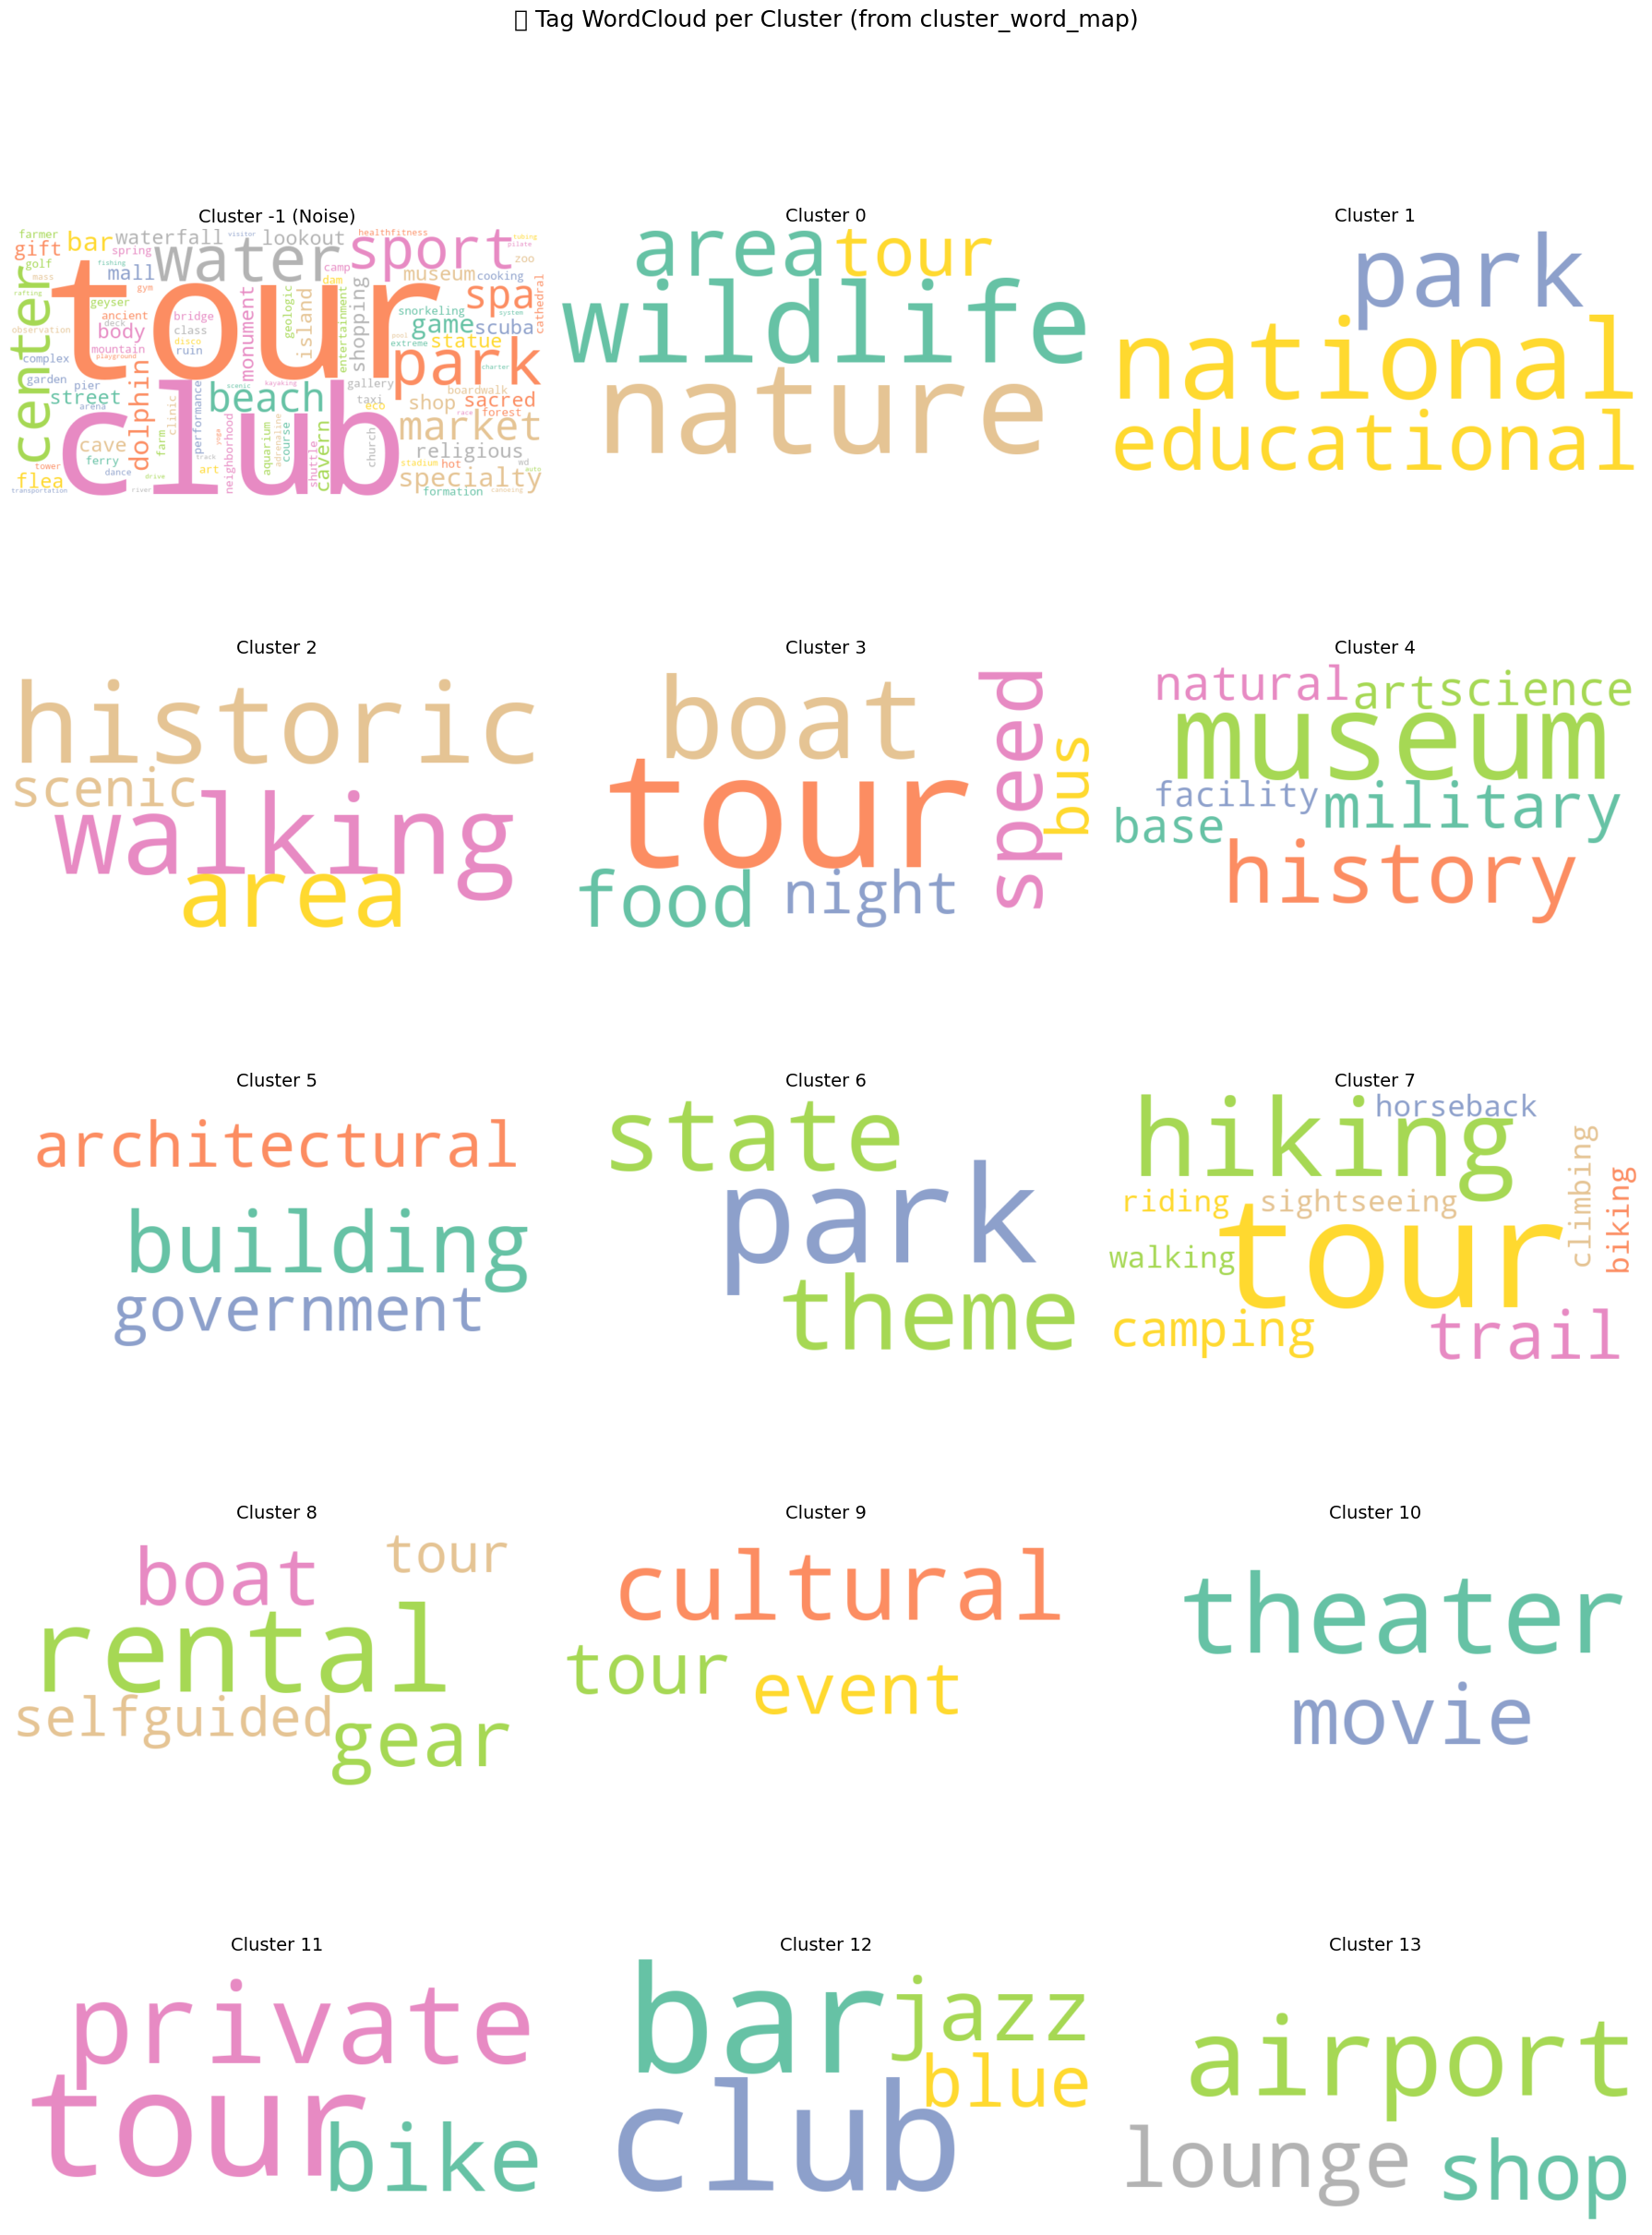

In [79]:
cluster_ids = sorted(cluster_word_map.keys())
n_clusters = len(cluster_ids)

# ✅ สร้างแคนวาส 3 คอลัมน์แบบดูดี
cols = 3
rows = math.ceil(n_clusters / cols)
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

# ✅ วาด WordCloud ต่อคลัสเตอร์
for idx, cluster_id in enumerate(cluster_ids):
    words = cluster_word_map[cluster_id]
    text_blob = " ".join(words)
    
    wordcloud = WordCloud(
        background_color="white",
        colormap="Set2",
        max_words=100,
        width=800,
        height=400
    ).generate(text_blob)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].axis("off")
    title = f"Cluster {cluster_id}" if cluster_id != -1 else "Cluster -1 (Noise)"
    axes[idx].set_title(title, fontsize=14)

# ✅ ปิด plot ที่เหลือ (ถ้ามี)
for j in range(idx + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("🧩 Tag WordCloud per Cluster (from cluster_word_map)", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [158]:
combined_details_df.to_parquet("output/cosine_clusters.parquet", index=False)